In [ ]:
# Import the Google Drive module (Colab only)
from google.colab import drive

# Mount your Google Drive to the Colab runtime
# You will be prompted to authorize access
drive.mount("/content/drive")

# Set the folder path where your data files are stored
# Update this path to match the location of your files in Google Drive
DATA_DIR = "/content/drive/My Drive/Colab Notebooks"

Mounted at /content/drive


In [ ]:
import pandas as pd

# Define path
file_path = f"{DATA_DIR}/Employee attrition.csv"

# Load data: skipping the first 'junk' row and setting the header properly
df = pd.read_csv(file_path, skiprows=1, header=0)

# Check the results
print(f"Success! Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.head())

Success! Dataset has 1470 rows and 35 columns.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load data - skipping the first descriptive line
df = pd.read_csv(f'{DATA_DIR}/Employee attrition.csv', skiprows=1)

# A. CLEANING: Drop irrelevant or constant columns
# These don't help prediction because they are the same for everyone or are just IDs
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'])

# B. TARGET ENCODING: Convert 'Attrition' to 1 (Yes) and 0 (No)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# C. FEATURE ENCODING: Turn categories (like MaritalStatus) into numbers
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# D. DEFINE X AND Y
X = df_final.drop('Attrition', axis=1)
y = df_final['Attrition']

In [ ]:
# Convert text target to numeric
df['Attrition_Binary'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

In [ ]:
from sklearn.model_selection import train_test_split

# Choosing a few clear numeric features to start
X = df[['Age', 'MonthlyIncome', 'JobSatisfaction', 'TotalWorkingYears', 'YearsAtCompany']]
y = df['Attrition_Binary']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. LOAD DATA correctly (skipping the title row)
df = pd.read_csv(f'{DATA_DIR}/Employee attrition.csv', skiprows=1)

# 2. DATA CLEANING
# Drop columns that are identical for everyone or just ID numbers
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'])

# Convert the Target 'Attrition' to numbers (REQUIRED for Logistic Regression)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# 3. DUMMY ENCODING
# This turns categories like 'OverTime' and 'MaritalStatus' into numbers
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 4. DEFINE X AND Y
X = df_final.drop('Attrition', axis=1)
y = df_final['Attrition']

# 5. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 6. SCALING (This fixes most Logistic Regression errors/warnings)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. RUN LOGISTIC REGRESSION
# We use a high max_iter to ensure the model finishes calculating
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_scaled, y_train)

# 8. RESULTS
y_pred = log_reg.predict(X_test_scaled)
print("--- MODEL PERFORMANCE ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

# 9. INTERPRETATION (Odds Ratios)
# This part is key for your report section on Work-Life Balance
coeffs = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]})
coeffs['Odds_Ratio'] = np.exp(coeffs['Coefficient'])
print("\n--- WORK-LIFE BALANCE IMPACT ---")
print(coeffs[coeffs['Feature'] == 'WorkLifeBalance'])

--- MODEL PERFORMANCE ---
Accuracy Score: 0.88

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       370
           1       0.72      0.41      0.52        71

    accuracy                           0.88       441
   macro avg       0.81      0.69      0.73       441
weighted avg       0.87      0.88      0.87       441


--- WORK-LIFE BALANCE IMPACT ---
            Feature  Coefficient  Odds_Ratio
18  WorkLifeBalance    -0.287716    0.749975


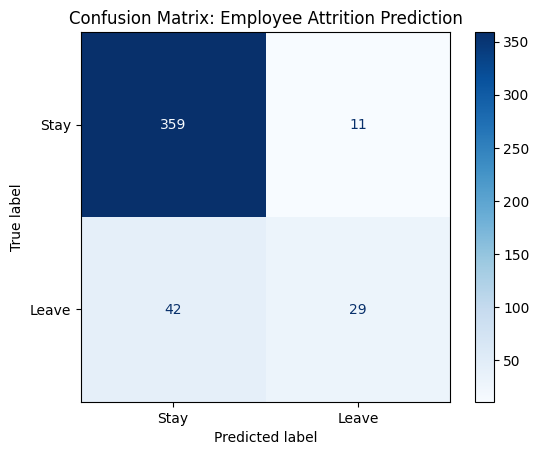

Classification Metrics Summary
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       370
           1       0.72      0.41      0.52        71

    accuracy                           0.88       441
   macro avg       0.81      0.69      0.73       441
weighted avg       0.87      0.88      0.87       441

Positive rate (share of employees who left): 0.161
Naive 'predict Stay for everyone' accuracy: 0.839


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Generate the confusion matrix
# Rows = actual outcomes (Stay/Leave)
# Columns = model predictions
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
# Updated labels: 0 = "Stay", 1 = "Leave"
disp = ConfusionMatrixDisplay(
    cm,
    display_labels=["Stay", "Leave"]
)

# Plotting
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Employee Attrition Prediction")
plt.show()

# Classification metrics summary
# Includes precision, recall, f1-score, and accuracy
print("Classification Metrics Summary")
print(classification_report(y_test, y_pred, zero_division=0))

# Baseline comparison: positive rate
# This is the proportion of employees who actually left (y = 1)
positive_rate = y_test.mean()

# A naive model that predicts "Stay" for everyone
# would have an accuracy of approximately (1 - positive_rate)
print(f"Positive rate (share of employees who left): {positive_rate:.3f}")
print(f"Naive 'predict Stay for everyone' accuracy: {1 - positive_rate:.3f}")

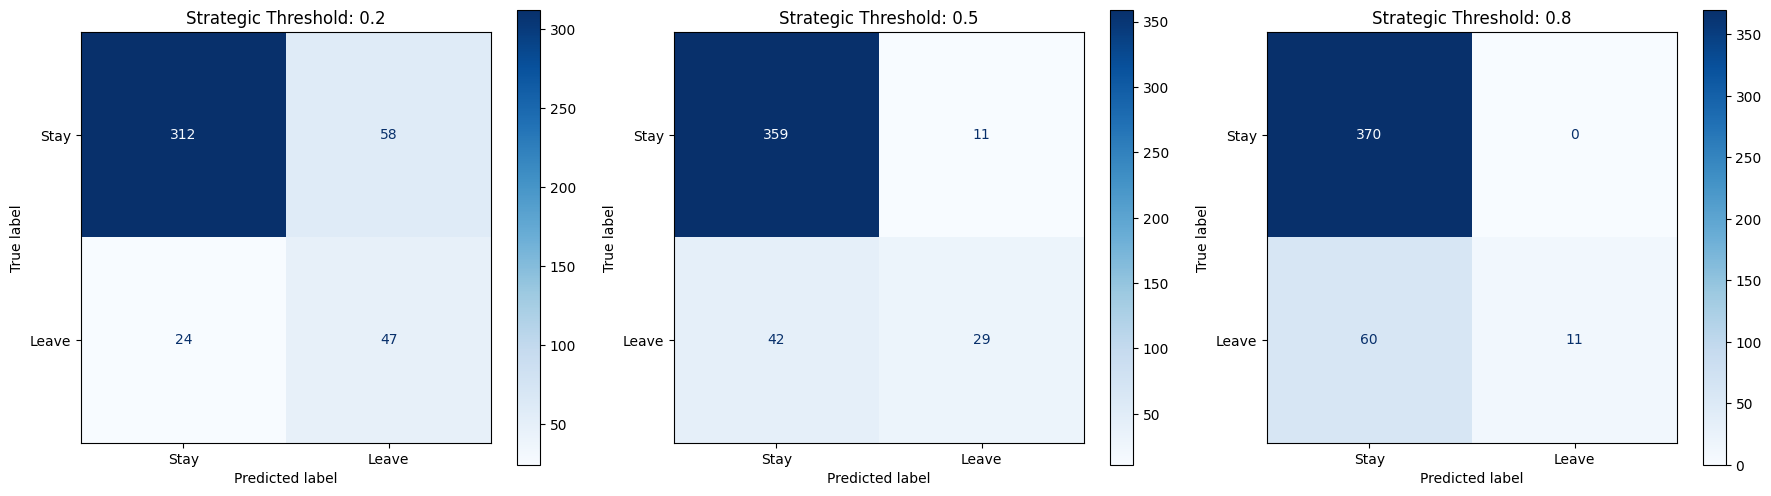

--- STRATEGIC METRICS SUMMARY ---
Threshold 0.2: Accuracy=0.81 | Recall=0.66 | Precision=0.45
Threshold 0.5: Accuracy=0.88 | Recall=0.41 | Precision=0.72
Threshold 0.8: Accuracy=0.86 | Recall=0.15 | Precision=1.00


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np

# 1. Get the predicted probabilities (not just the 0 or 1)
# This gives the likelihood of each employee leaving
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

# 2. Define the thresholds to test
# 0.2 = Aggressive (catch everyone), 0.5 = Balanced, 0.8 = Conservative (be certain)
thresholds = [0.2, 0.5, 0.8]

# 3. Create a side-by-side visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, t in enumerate(thresholds):
    # Convert probabilities to 1 or 0 based on the threshold 't'
    y_pred_t = (y_probs >= t).astype(int)

    # Calculate matrix
    cm = confusion_matrix(y_test, y_pred_t)

    # Visualize using the class style (ConfusionMatrixDisplay)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stay", "Leave"])
    disp.plot(cmap="Blues", ax=axes[i], values_format='d')
    axes[i].set_title(f"Strategic Threshold: {t}")

plt.tight_layout()
plt.show()

# 4. Print Summary for your Report
print("--- STRATEGIC METRICS SUMMARY ---")
for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True, zero_division=0)
    print(f"Threshold {t}: Accuracy={report['accuracy']:.2f} | Recall={report['1']['recall']:.2f} | Precision={report['1']['precision']:.2f}")